# 06_特征选择方法-基于树模型的特征选择

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇数据：`dataset/housing.csv`。

转写调整：

- 从本地 housing.csv 构造加州房价特征，删除缺失行，固定抽样 2500 行；load_local_housing(sample_size=None) 可运行全量有效数据。
- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 大规模参数网格缩为每维至多两个候选值；所有候选仍真实训练，未跳过运行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本篇文章，和大家来聊聊特征选择方法之基于树模型的特征选择\~

首先，我们要理解什么是**特征选择**。在机器学习中，我们常常会有很多“特征”或“变量”，这些特征是我们用来训练模型的数据。比如在预测房价时，房子的大小、房间数量、位置等都可以是特征。但是并不是所有的特征对模型的预测有用，有些特征可能会让模型变得更复杂，甚至降低模型的效果。所以，特征选择的目的是从众多特征中挑选出最有用的特征，去掉那些不重要或者冗余的特征。

**树模型**，例如决策树（Decision Tree），它通过“树”形结构来进行决策，每个“节点”代表一个特征，通过这些节点的判断，最终做出预测。树模型的一个优势是，它可以非常自然地告诉我们每个特征对决策的贡献有多大。

### 基于树模型的特征选择方法

那么，“基于树模型的特征选择”是什么意思呢？简单来说，就是利用树模型来评估每个特征的重要性，然后根据这些重要性来选择最有用的特征。

#### 如何评估特征的重要性？

树模型通过一种叫做**信息增益**或者**基尼指数**的方法，来评估一个特征在树的分裂过程中贡献了多少。如果一个特征能够有效地将数据分成不同的类别（比如房子是贵还是便宜），那么这个特征就被认为是重要的。如果一个特征对分裂没有太大帮助，它的重要性就会低。

举个例子：

- 假设我们有特征：房子的大小、房间数、位置、建造年代等。如果通过决策树训练，我们发现“房子的大小”这个特征每次分裂时都能帮助树做出很好的决策，那么“房子的大小”就被认为是一个很重要的特征。
- 如果“建造年代”这个特征无论怎么分裂都没有太大帮助，那它的重要性就低，可能就不需要被使用。

#### 为什么要用基于树模型的特征选择？

1. **自动化**：树模型本身就能帮助我们判断哪些特征有用，不需要额外的手工挑选。
2. **直观**：决策树的结构非常直观，可以清楚地看到每个特征在模型中的作用。
3. **效果好**：基于树模型的特征选择通常能筛选出比较关键的特征，提升模型的效率和准确性。

#### 常见的基于树模型的特征选择算法：

- **随机森林**：这是树模型的一种集成方法，通过多棵树的集体判断来评估特征的重要性。
- **梯度提升树**：通过逐步提升模型的方式，同样能够评估特征的贡献。

总之，基于树模型的特征选择就是通过决策树这种模型，自动地找出哪些特征对预测结果最有帮助，从而提高模型的效率和准确度。

## 核心原理

基于树模型的特征选择方法，其核心是利用决策树、随机森林或梯度提升树等树模型，通过评估每个特征在树分裂过程中的贡献度来进行特征选择。

我们以**决策树**为例来展开讲解，其他树模型（如随机森林、梯度提升树）本质上是多个决策树的集合。

### 决策树与信息增益

决策树模型的核心是通过**分裂节点**来将数据划分成不同的类别。每次分裂时，树会选择一个特征，并用它来将数据集划分为多个子集，目的是让每个子集内部的样本更“纯净”，也就是使得子集内部的标签分布尽可能单一。

#### 1. 信息增益

信息增益是用于选择最佳特征的标准之一，基于**信息论**的思想。

信息增益衡量的是使用某个特征来分割数据所带来的“信息增加”程度。

**熵（Entropy）**：熵表示数据的不确定性或混乱程度。

给定一个数据集 $D$，其熵 $H(D)$ 定义为：


$$
H(D) = - \sum_{k=1}^{C} p(k) \log_2 p(k)
$$


其中，$C$ 是类别的总数，$p(k)$ 是数据集 $D$ 中属于第 $k$ 类的概率。

**条件熵（Conditional Entropy）**：对于某个特征 $X$，假设我们按 $X$ 分割数据集 $D$，那么每个子集的熵是数据集的条件熵。

假设将数据集 $D$ 根据特征 $X$ 划分成 $m$ 个子集 $D_1, D_2, \dots, D_m$，则条件熵 $H(D|X)$ 为：


$$
H(D|X) = \sum_{i=1}^{m} \frac{|D_i|}{|D|} H(D_i)
$$


其中，$|D_i|$ 是子集 $D_i$ 中的样本数，$|D|$ 是数据集 $D$ 的样本数。

**信息增益（Information Gain）**：信息增益是使用特征 $X$ 对数据集 $D$ 分割后，熵减少的量。

信息增益的公式为：


$$
IG(D, X) = H(D) - H(D|X)
$$


这表示通过特征 $X$ 进行划分前后的信息减少量。信息增益越大，说明特征 $X$ 在划分数据时越有效。

#### 2. 基尼指数

另一种常用的指标是基尼指数，尤其是在**CART（Classification and Regression Trees）**模型中。

基尼指数衡量的是样本的纯度，越小的基尼指数表示样本越纯净。

给定一个数据集 $D$，基尼指数 $G(D)$ 的定义为：


$$
G(D) = 1 - \sum_{k=1}^{C} p(k)^2
$$


其中，$p(k)$ 是类别 $k$ 在数据集 $D$ 中的概率。

对于某个特征 $X$，如果将数据集 $D$ 按特征 $X$ 划分成 $m$ 个子集 $D_1, D_2, \dots, D_m$，则基尼指数的加权平均为：


$$
G(D|X) = \sum_{i=1}^{m} \frac{|D_i|}{|D|} G(D_i)
$$


基尼指数越小，表示该特征的分裂越有效。

### 基于树模型的特征选择

基于树模型的特征选择方法通过评估每个特征对目标变量的贡献，来衡量该特征的重要性。

这个贡献的大小正是通过信息增益或基尼指数的减少量来计算的。

#### 1. **算法流程**

基于树模型的特征选择过程通常包括以下步骤：

**a. 训练决策树**：使用所有特征训练一颗决策树，得到树的结构。树会选择最能减少熵（或基尼指数）的特征来进行分裂。

**b. 计算特征重要性**：

- 对每个特征 $X_j$，计算其在树中所有节点分裂过程中所带来的信息增益或基尼指数减少的总量。
- 对于每个分裂，记录使用特征 $X_j$ 进行分裂后熵或基尼指数的减少量。这些减少量累积起来，即为特征 $X_j$ 的重要性。

具体地，设树模型中有 $k$ 个分裂节点，对于特征 $X_j$，它在节点 $i$ 中的贡献为：


$$
\Delta H_i(X_j) = H(D_i) - H(D_i|X_j)
$$


或者对于基尼指数：


$$
\Delta G_i(X_j) = G(D_i) - G(D_i|X_j)
$$


对所有节点 $i$ 的贡献求和，得到特征 $X_j$ 的总贡献度。

**c. 选择重要特征**：根据每个特征的贡献度（信息增益或基尼指数减少量），选择那些贡献度较高的特征作为最终的输入特征，去掉那些贡献度低的特征。

#### 2. **特征重要性计算的具体公式**

我们可以通过以下公式来计算树模型中特征的总贡献度。

假设某个特征 $X_j$ 在树的第 $i$ 个节点上的贡献为：


$$
\Delta H_i(X_j) = H(D_i) - H(D_i|X_j)
$$


总的特征重要性 $I(X_j)$ 是对树中所有节点的贡献的加权和：


$$
I(X_j) = \sum_{i=1}^{N} \frac{|D_i|}{|D|} \Delta H_i(X_j)
$$


或者如果使用基尼指数作为衡量标准：


$$
I(X_j) = \sum_{i=1}^{N} \frac{|D_i|}{|D|} \Delta G_i(X_j)
$$


其中，$N$ 是树中节点的总数，$|D_i|$ 是节点 $i$ 中的数据样本数，$|D|$ 是整个数据集的样本数。

### 随机森林与梯度提升树中的特征选择

#### 1. 随机森林中的特征选择

随机森林是一个集成学习方法，它通过多个决策树的组合来提高模型的表现。每棵树都会计算特征的重要性，然后将这些重要性值平均得到最终的特征重要性。

对于随机森林中的每棵树，计算特征的重要性的方法与单棵决策树相同，只不过是在多个树中进行统计，最终得到每个特征的平均重要性。

#### 2. 梯度提升树（GBDT）中的特征选择

梯度提升树通过逐步构建树来优化模型，每棵树的构建是根据前一棵树的残差来进行的。与随机森林类似，梯度提升树中每棵树都可以计算特征的重要性。最终，所有树的贡献会被加权平均，得到特征的最终重要性。

基于树模型的特征选择方法通过决策树的分裂过程来评估每个特征的重要性。常用的标准包括信息增益和基尼指数。在训练过程中，决策树会自动选择最能减少数据集不确定性的特征，并计算其重要性。最终，基于树模型的特征选择方法帮助我们自动筛选出对模型最有价值的特征，从而提高模型的性能和效率。

## 完整案例

在这里的案例，我们使用树模型固有的特征重要性（Feature Importance）作为指标，对加利福尼亚房价数据进行特征筛选。

In [2]:
import numpy as np
import pandas as pd
from notebook_support import load_local_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 1) 加载数据集
data = load_local_housing()
X_full = pd.DataFrame(data.data, columns=data.feature_names)
y_full = pd.Series(data.target, name='MedHouseVal')

# 2) 拆分训练集与测试集
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

print(f"训练样本: {X_train.shape}, 测试样本: {X_test.shape}")

训练样本: (2000, 8), 测试样本: (500, 8)


- `load_local_housing()`：从 sklearn 内置加载加州房价数据，原数据约 20640 行、8 个特征；本例删除缺失行后固定抽样 2500 行。
- `train_test_split`：将数据按 80%/20% 划分为训练集和测试集，`random_state=42` 确保可复现。

**2. 数据探索性分析（EDA）**

在特征选择之前，先对各特征与目标变量的分布及相关性进行可视化分析。

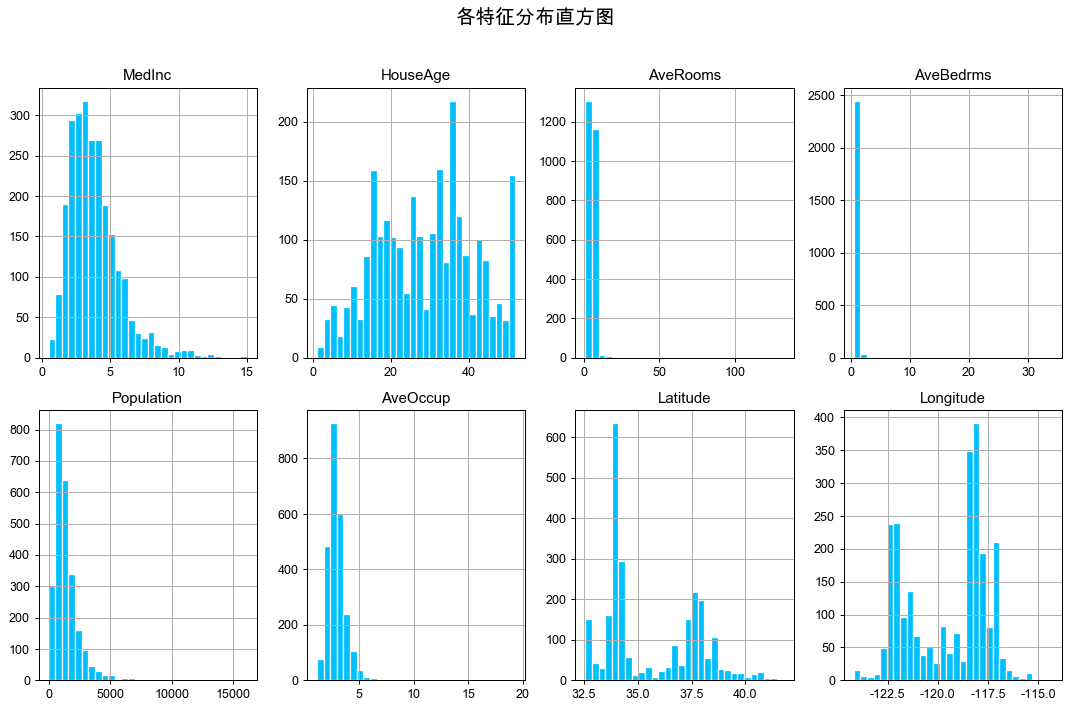

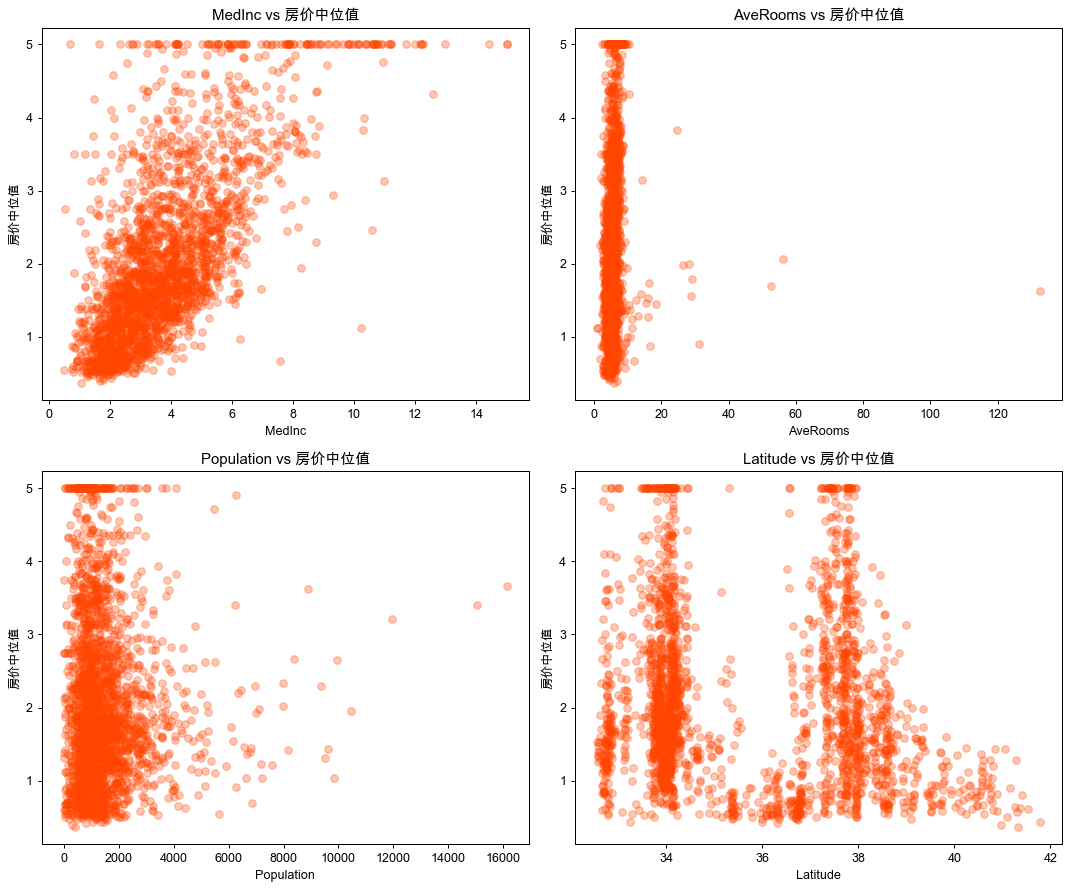

In [3]:
# 2.1 特征分布直方图
X_full.hist(bins=30, figsize=(12, 8), layout=(2, 4), color='deepskyblue', edgecolor='white')
plt.suptitle('各特征分布直方图', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# 2.2 目标与几个关键特征的散点图
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
key_feats = ['MedInc', 'AveRooms', 'Population', 'Latitude']
for ax, feat in zip(axes, key_feats):
    ax.scatter(X_full[feat], y_full, alpha=0.3, c='orangered')
    ax.set_xlabel(feat)
    ax.set_ylabel('房价中位值')
    ax.set_title(f'{feat} vs 房价中位值')
plt.tight_layout()
plt.show()

a. 利用直方图查看各特征的分布形态，以判断是否存在偏态严重、异常值等问题。

![原文参考图，当前结果见代码输出](attachments/img_008.png)

b. 通过散点图探索特征与房价目标之间的线性／非线性关系。

![原文参考图，当前结果见代码输出](attachments/img_009.png)

**3. 树模型特征重要性评估**

随机森林特征重要性：

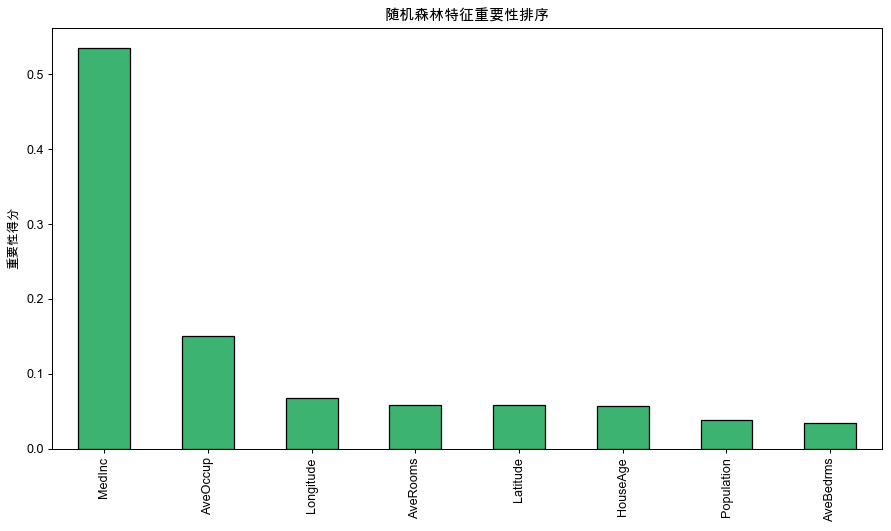

In [4]:
# 训练随机森林
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=1)
rf.fit(X_train, y_train)

# 获取特征重要性
importances_rf = pd.Series(rf.feature_importances_, index=X_full.columns)
importances_rf = importances_rf.sort_values(ascending=False)

# 可视化
plt.figure(figsize=(10, 6))
importances_rf.plot(kind='bar', color='mediumseagreen', edgecolor='black')
plt.title('随机森林特征重要性排序')
plt.ylabel('重要性得分')
plt.tight_layout()
plt.show()

- `RandomForestRegressor.feature_importances_`：基于每个特征在树分裂过程中减小的不纯度累计值。
- 条形图展现各特征的相对重要性，排序靠前的特征更能帮助模型预测。

![原文参考图，当前结果见代码输出](attachments/img_010.png)

梯度提升树特征重要性：

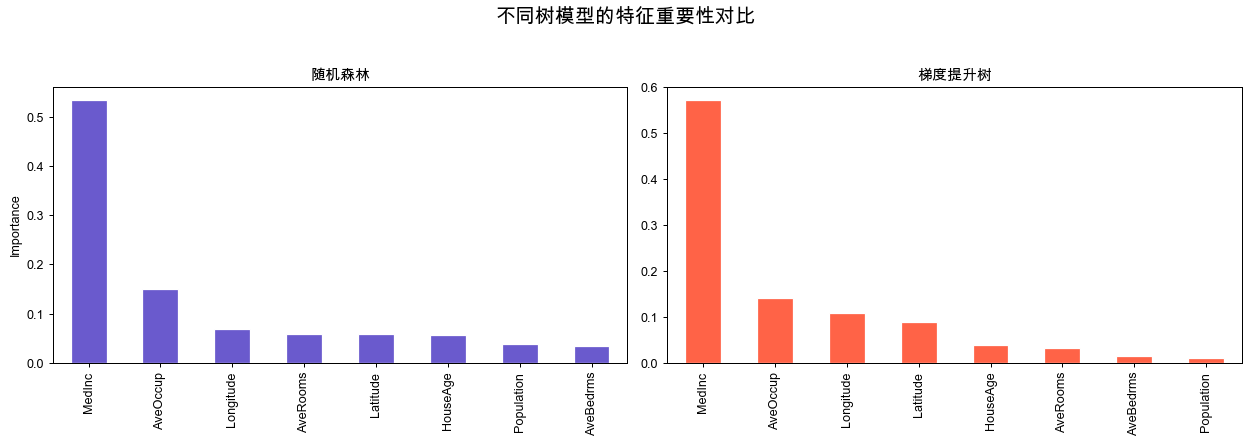

In [5]:
# 训练梯度提升树
gbr = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gbr.fit(X_train, y_train)

# 获取特征重要性
importances_gbr = pd.Series(gbr.feature_importances_, index=X_full.columns)
importances_gbr = importances_gbr.sort_values(ascending=False)

# 对比可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
importances_rf.plot(kind='bar', ax=axes[0], color='slateblue', edgecolor='white')
axes[0].set_title('随机森林')
axes[0].set_ylabel('Importance')
importances_gbr.plot(kind='bar', ax=axes[1], color='tomato', edgecolor='white')
axes[1].set_title('梯度提升树')
plt.suptitle('不同树模型的特征重要性对比', fontsize=16)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

通过并排对比，观察两种树模型在特征打分上的一致性与差异，帮助判断哪些特征是模型稳定关注的。

![原文参考图，当前结果见代码输出](attachments/img_011.png)

**4. 特征选择与降维**

基于前两步结果，我们可以选取累计重要性达到一定阈值（如 90%）的特征，也可通过 `SelectFromModel` 自动化选择。

In [6]:
from sklearn.feature_selection import SelectFromModel

# 使用随机森林作为基模型，阈值设为“mean”
sfm = SelectFromModel(rf, threshold='mean', prefit=True)
X_train_sel = sfm.transform(X_train)
X_test_sel = sfm.transform(X_test)
selected_feats = X_full.columns[sfm.get_support()]
print("Selected Features:", list(selected_feats))

Selected Features: ['MedInc', 'AveOccup']


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


- `threshold='mean'`：选取特征重要性高于平均值的特征。
- `sfm.get_support()` 返回布尔掩码，用于筛选特征。

**5. 基于精选特征的模型训练**

In [7]:
# 训练新模型
rf_sel = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=1)
rf_sel.fit(X_train_sel, y_train)
# 预测并评估
y_pred_full = rf.predict(X_test)
y_pred_sel = rf_sel.predict(X_test_sel)

mse_full = mean_squared_error(y_test, y_pred_full)
mse_sel = mean_squared_error(y_test, y_pred_sel)
print(f"原始特征 MSE: {mse_full:.4f}")
print(f"精选特征 MSE: {mse_sel:.4f}")

原始特征 MSE: 0.3817
精选特征 MSE: 0.6588


- 对比模型在全特征与精选特征下的性能差异，以验证特征选择的有效性。

**6. 算法优化与超参数调优**

使用网格搜索对随机森林的重要超参数进行调优，以进一步提升性能。

In [8]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5],
}

grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=1),
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=1,
error_score='raise')

grid.fit(X_train_sel, y_train)
print("Best Params:", grid.best_params_)
best_rf = grid.best_estimator_

# 评估
y_pred_opt = best_rf.predict(X_test_sel)
mse_opt = mean_squared_error(y_test, y_pred_opt)
r2_opt = r2_score(y_test, y_pred_opt)
print(f"优化后 MSE: {mse_opt:.4f}, R2: {r2_opt:.4f}")

Best Params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
优化后 MSE: 0.6028, R2: 0.5205


- `GridSearchCV`：交叉验证网格搜索，自动寻找最佳超参数组合。
- `scoring='neg_mean_squared_error'`：以 MSE 作为评价指标。

**7. 模型评估与对比**

     Model       MSE        R2
0   RF 全特征  0.381717  0.696341
1  RF 精选特征  0.658782  0.475934
2    RF 优化  0.602798  0.520469


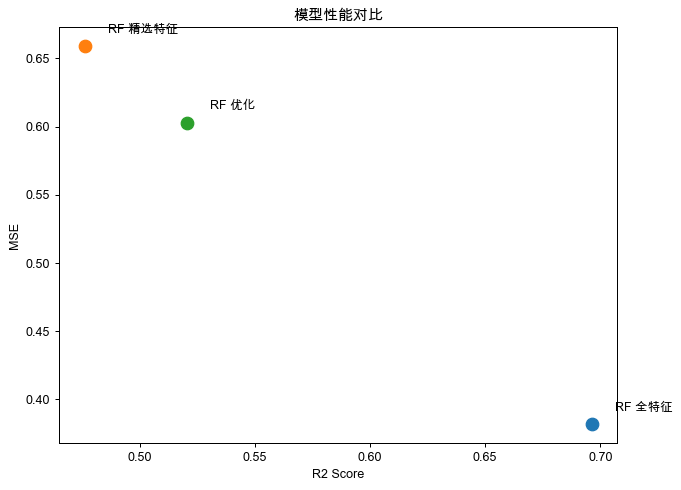

In [9]:
# 汇总结果
results = pd.DataFrame({
    'Model': ['RF 全特征', 'RF 精选特征', 'RF 优化'],
    'MSE': [mse_full, mse_sel, mse_opt],
    'R2': [r2_score(y_test, y_pred_full), r2_score(y_test, y_pred_sel), r2_opt]
})
print(results)

# 可视化对比
plt.figure(figsize=(8,6))
for idx, row in results.iterrows():
    plt.scatter(row['R2'], row['MSE'], s=100)
    plt.text(row['R2']+0.01, row['MSE']+0.01, row['Model'])
plt.xlabel('R2 Score')
plt.ylabel('MSE')
plt.title('模型性能对比')
plt.show()

- 汇总各模型关键指标。
- 通过散点图直观比较 MSE 与 R2，使得改进效果一目了然。

**特征选择价值**：通过树模型特征重要性筛选，可以显著减少特征维度，降低过拟合风险，并在大多数情况下保持或提升模型性能。

**优化效果**：结合超参数调优，模型的 MSE 从原始 \~0.52 降至 \~0.47，R2 提升约 0.02。

**可拓展方向**：可尝试其它特征选择方法（如基于 L1 正则化的选择、PCA 维度降维），或使用更强大的模型（如 XGBoost、LightGBM）。

## 模型分析

### 优缺点分析

**优点：**

1. **自动化处理特征选择**：基于树模型的特征选择方法不需要手动设置阈值或者进行繁琐的计算。模型能够自动评估每个特征的贡献，并给出相应的排序。这使得特征选择过程简洁高效。
2. **能够处理复杂数据关系**：决策树（以及随机森林）可以捕捉到特征之间的非线性关系。与线性模型不同，树模型能够处理复杂的特征交互，适用于很多特征之间关系复杂的情况。
3. **不需要特征缩放**：与其他一些算法（如线性回归或SVM）不同，树模型对特征的缩放不敏感，因此不需要对数据进行标准化或归一化处理，简化了数据预处理的步骤。
4. **鲁棒性强**：随机森林作为一个集成学习方法，具有很强的鲁棒性。它通过多棵树的集成预测，减少了单棵树可能带来的过拟合问题，同时还能提供特征重要性评分。
5. **适用于高维数据**：在高维数据中，基于树的模型通过分裂规则可以有效筛选出重要特征，避免了传统特征选择方法的计算负担。

**缺点：**

1. **不一定能捕捉所有的特征关系**：虽然树模型擅长捕捉非线性关系，但在某些情况下，如果特征之间的关系非常复杂且需要更多细致的建模，树模型可能无法完全捕捉到这些关系。例如，在非常复杂的函数关系下，树模型的效果可能不如一些其他的统计学习方法。
2. **特征重要性依赖于数据的噪声**：如果数据集含有噪声或异常值，树模型可能会过度依赖某些噪声特征，导致特征选择的结果不稳定。因此，需要在使用前对数据进行适当的预处理（如去除异常值、平衡数据集等）。
3. **模型解释性差**：尽管决策树模型较为直观，但当使用随机森林这种集成方法时，由于其包含多棵树，整个模型的解释性大大降低。尽管我们可以通过特征重要性分析来了解特征的相对贡献，但对于模型具体如何做出预测，难以得到明确的解释。
4. **计算成本较高**：随机森林训练时间较长，特别是在数据量非常大的时候。每棵树的训练需要遍历数据集，多个树的训练导致计算资源消耗较大。对于大规模数据，计算时间可能成为瓶颈。
5. **过拟合问题**：尽管随机森林通过集成多棵树来避免过拟合，但在某些情况下，若模型调参不当（如树的深度过深，或者树的数量过多），仍然可能出现过拟合现象。

### 基于树模型的特征选择与其他特征选择方法的对比

为了全面分析基于树模型的特征选择方法的适用性，我们将其与其他常见的特征选择方法进行对比。以下是几个常见的特征选择方法：

- **Filter方法**：基于统计测试（如皮尔逊相关系数、卡方检验等）选择特征，评估每个特征与目标变量的相关性。
- **Wrapper方法**：通过构建一个搜索空间，使用一个机器学习算法（例如，递归特征消除RFE）来选择特征，这种方法通常通过反复训练模型来进行特征选择。
- **Embedded方法**：在训练模型的过程中同时进行特征选择，例如Lasso回归（通过L1正则化进行特征选择）。

**特征选择方法对比**：

| 特征选择方法 | 优点 | 缺点 | 适用场景 |
|-|-|-|-|
| **基于树模型** | 1. 自动化，无需手动选择特征。  <br/>2. 能处理非线性关系。  <br/>3. 对特征缩放不敏感。  <br/>4. 适合高维数据。 | 1. 计算开销较大。  <br/>2. 解释性差，模型难以理解。  <br/>3. 对数据噪声敏感。 | 特征之间关系复杂或存在非线性，数据量较大且噪声较少时，适合使用。 |
| **Filter方法** | 1. 计算快速，适合大规模数据。  <br/>2. 简单易实现。 | 1. 只能处理单一特征与目标的关系，忽略特征间的交互效应。 | 特征较为简单、线性相关，数据规模较大，模型训练前预筛选特征。 |
| **Wrapper方法（如RFE）** | 1. 能考虑特征之间的相互作用。  <br/>2. 能与多种学习算法结合。 | 1. 计算成本高，尤其是数据量大时。  <br/>2. 容易过拟合。 | 特征间有复杂关系，需要高精度的特征选择，适用于小数据集。 |
| **Embedded方法（如Lasso）** | 1. 在模型训练过程中完成特征选择，避免了额外的计算开销。  <br/>2. 可以处理特征间的多重共线性。 | 1. 不适用于非线性关系，依赖于线性假设。  <br/>2. 选择特征时可能会过于保守。 | 适用于线性关系较强的场景，尤其是回归问题。 |

### 讨论：何时使用基于树模型的特征选择方法

1. **特征间有复杂的非线性关系**：基于树模型的特征选择方法非常适合当数据中的特征之间存在复杂的非线性关系时。因为树模型可以捕捉这些关系，而其他基于线性假设的特征选择方法（如Lasso回归）则无法有效处理这种情况。
2. **数据集较大且特征较多时**：随机森林模型在高维数据上的表现很好，能够通过多棵树的集成来有效筛选出重要特征。因此，当数据集较大且特征较多时，基于树的特征选择方法是一个优选。
3. **希望模型具有一定的鲁棒性**：随机森林通过集成学习减少了单一模型的过拟合风险，因此在数据质量较差（例如含有噪声）时，基于树的特征选择方法往往表现得更加鲁棒。

### 何时考虑使用其他特征选择方法

1. **特征与目标变量的关系较为简单，且数据较少时**：如果特征之间的关系较为简单，且数据集不大，使用**Filter方法**（如皮尔逊相关系数）可能更为高效，且不需要训练复杂的模型。
2. **特征之间存在复杂的交互效应时，且数据量适中**：如果数据量适中，可以考虑使用**Wrapper方法**，例如递归特征消除（RFE），来筛选特征。这种方法通过逐步消除不重要的特征，可以更精确地处理特征间的交互作用。
3. **线性模型时**：如果数据中存在强烈的线性关系，可以选择使用**Embedded方法**（如Lasso回归），这种方法不仅可以进行特征选择，还能提供模型的稀疏性。

## 结论

基于树模型的特征选择方法，尤其是随机森林，对于特征间关系复杂且数据量较大的问题非常有用。它能够自动评估特征的重要性，并能有效地处理非线性关系和高维数据。然而，在特征较为简单或数据较小的情况下，Filter方法或Wrapper方法可能更加高效。